In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [40]:
df = pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [41]:
df.shape

(200, 5)

In [42]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [43]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [45]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


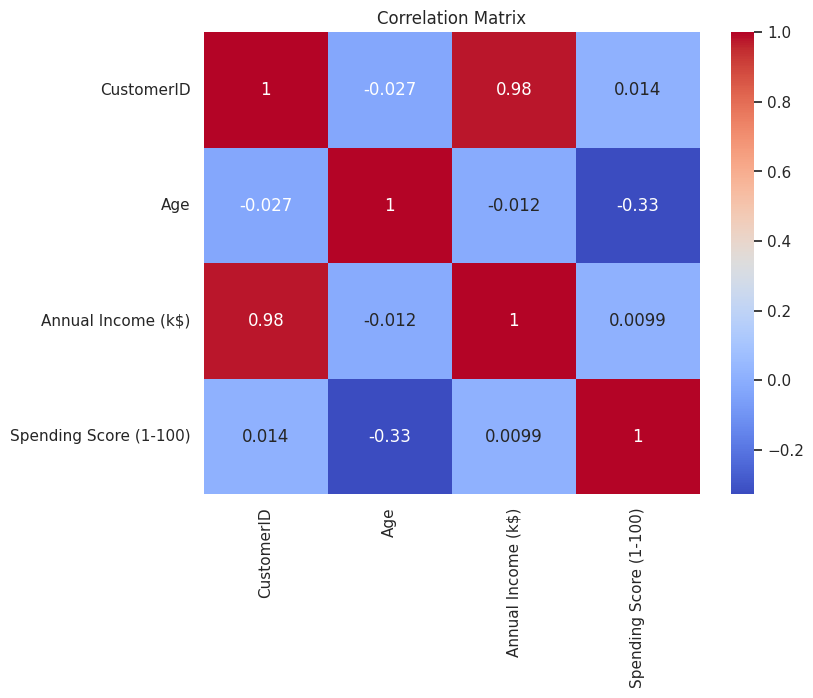

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

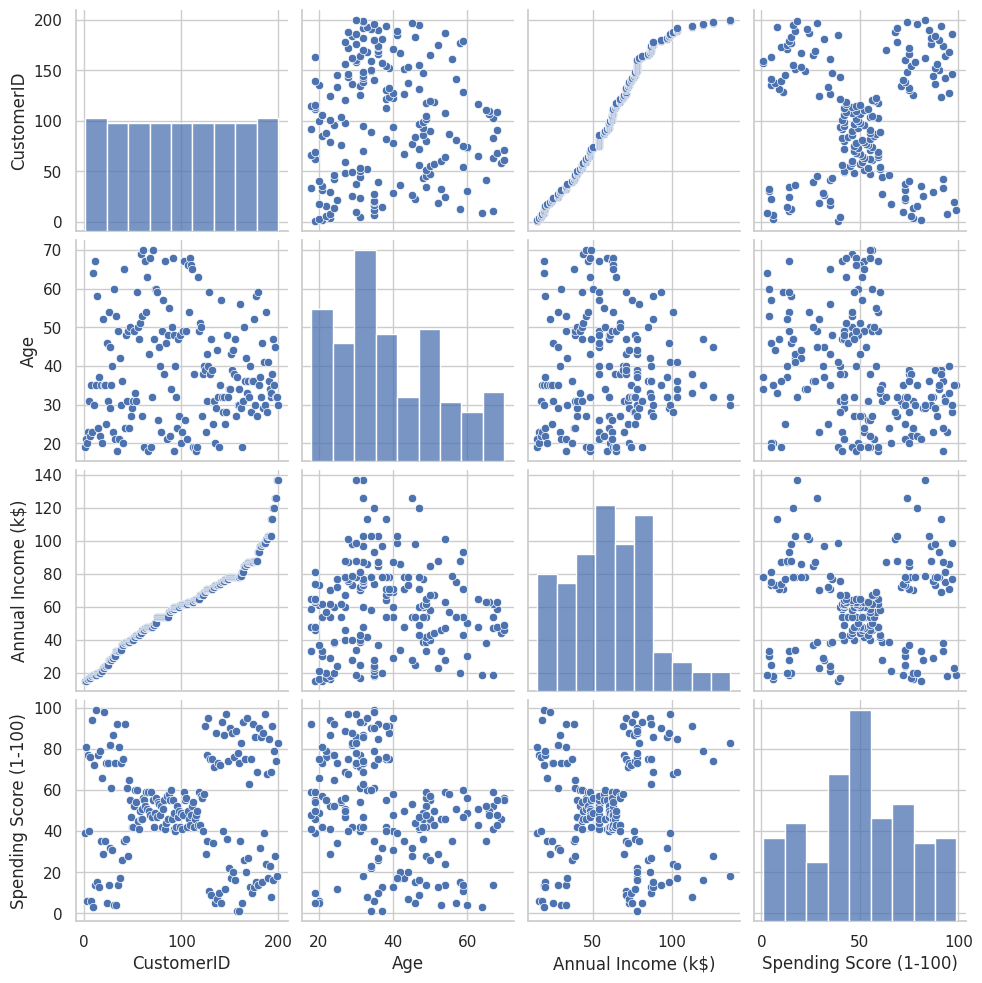

In [47]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

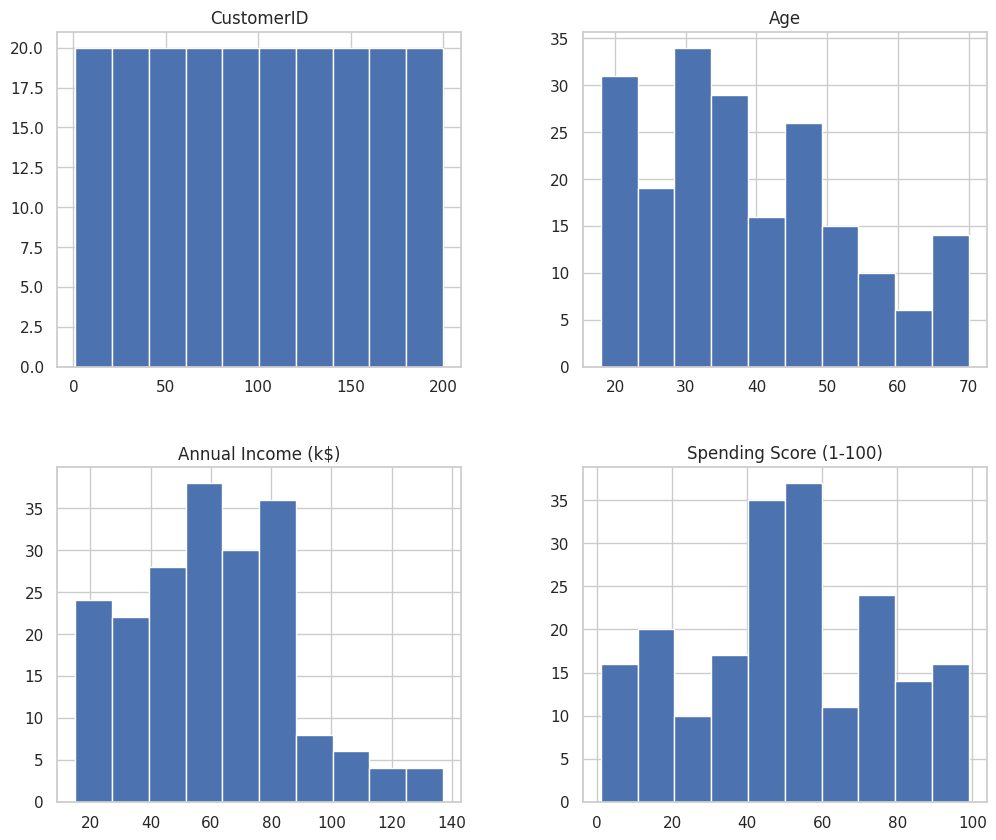

In [48]:
df.hist(figsize=(12,10))
plt.show()

In [49]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
encoder = OrdinalEncoder()
df[cat_cols] = encoder.fit_transform(df[cat_cols])

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

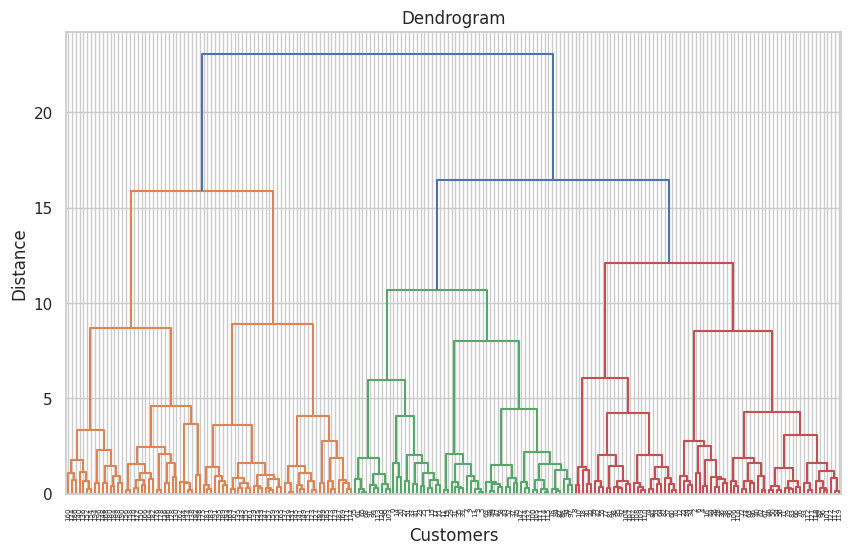

In [51]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [52]:
from sklearn.metrics import silhouette_score

linkages = ['ward', 'complete', 'average', 'single']
results = []

for linkage in linkages:
    print(f"\n🔹 Linkage: {linkage}")

    for k in range(2, 10):

        if linkage == 'ward':
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        else:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric='euclidean')

        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)

        results.append((linkage, k, score))
        print(f"k={k}, Silhouette Score={score:.4f}")


🔹 Linkage: ward
k=2, Silhouette Score=0.2512
k=3, Silhouette Score=0.2364
k=4, Silhouette Score=0.2926
k=5, Silhouette Score=0.3045
k=6, Silhouette Score=0.3273
k=7, Silhouette Score=0.3410
k=8, Silhouette Score=0.3669
k=9, Silhouette Score=0.3870

🔹 Linkage: complete
k=2, Silhouette Score=0.2512
k=3, Silhouette Score=0.2257
k=4, Silhouette Score=0.2798
k=5, Silhouette Score=0.2735
k=6, Silhouette Score=0.2704
k=7, Silhouette Score=0.2719
k=8, Silhouette Score=0.2612
k=9, Silhouette Score=0.2799

🔹 Linkage: average
k=2, Silhouette Score=0.2484
k=3, Silhouette Score=0.2709
k=4, Silhouette Score=0.2995
k=5, Silhouette Score=0.3084
k=6, Silhouette Score=0.3107
k=7, Silhouette Score=0.3389
k=8, Silhouette Score=0.3371
k=9, Silhouette Score=0.3634

🔹 Linkage: single
k=2, Silhouette Score=0.2334
k=3, Silhouette Score=0.1407
k=4, Silhouette Score=0.1174
k=5, Silhouette Score=0.0610
k=6, Silhouette Score=0.0480
k=7, Silhouette Score=0.0206
k=8, Silhouette Score=0.0189
k=9, Silhouette Score=-0